# Лабораторная работа: базовый ML-пайплайн

## 1. Разведочный анализ данных (EDA)

В этом разделе я:
- загружаю датасет из папки data внутри репозитория;
- проверяю структуру, пропуски и дубликаты;
- анализирую распределения признаков;
- визуализирую связи между переменными;
- формулирую краткие выводы по качеству данных.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

DATA_DIR = Path('data')
DATA_PATH = DATA_DIR / 'student_lifestyle_100k.csv'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('DATA_PATH:', DATA_PATH)

DATA_PATH: data\student_lifestyle_100k.csv


In [33]:
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
display(df.head())
display(df.sample(5, random_state=RANDOM_STATE))

print('\nInfo:')
df.info()

print('\nDescribe:')
display(df.describe(include='all').T)

missing = df.isna().sum().sort_values(ascending=False)
print('\nMissing values:')
display(missing)

print('\nDuplicates:', df.duplicated().sum())

anomaly_checks = {
    'age_below_0': (df['Age'] < 0).sum(),
    'sleep_out_of_range': ((df['Sleep_Duration'] < 0) | (df['Sleep_Duration'] > 24)).sum(),
    'study_out_of_range': ((df['Study_Hours'] < 0) | (df['Study_Hours'] > 24)).sum(),
    'cgpa_out_of_range': ((df['CGPA'] < 0) | (df['CGPA'] > 4.0)).sum(),
}
print('\nAnomaly checks:')
display(pd.Series(anomaly_checks))

Shape: (100000, 11)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
75721,76722,19,Male,Medical,2.29,5.0,1.3,3.2,14,3,False
80184,81185,23,Female,Business,3.73,7.2,4.7,3.1,9,5,False
19864,20865,21,Male,Engineering,2.60,7.3,4.5,3.2,70,2,False
76699,77700,20,Female,Science,2.91,6.7,1.6,3.0,122,2,False
92991,93992,24,Male,Engineering,3.59,6.7,4.1,3.6,9,5,False



Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB

Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,100000.0,NaN,NaN,NaN,51000.5,28867.657797,1001.0,26000.75,51000.5,76000.25,101000.0
Age,100000.0,NaN,NaN,NaN,21.00901,2.000382,18.0,19.0,21.0,23.0,24.0
Gender,100000,2,Male,50120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,100000,5,Science,20071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CGPA,100000.0,NaN,NaN,NaN,2.898316,0.53224,1.56,2.45,2.9,3.35,4.0
Sleep_Duration,100000.0,NaN,NaN,NaN,6.996425,1.498682,3.0,6.0,7.0,8.0,12.0
Study_Hours,100000.0,NaN,NaN,NaN,4.509517,1.976076,0.0,3.2,4.5,5.8,12.8
Social_Media_Hours,100000.0,NaN,NaN,NaN,3.503288,1.486852,0.0,2.5,3.5,4.5,10.0
Physical_Activity,100000.0,NaN,NaN,NaN,74.35318,43.366963,0.0,37.0,74.0,112.0,149.0
Stress_Level,100000.0,NaN,NaN,NaN,4.13166,1.424151,2.0,3.0,4.0,5.0,10.0



Missing values:


Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


Duplicates: 0

Anomaly checks:


age_below_0           0
sleep_out_of_range    0
study_out_of_range    0
cgpa_out_of_range     0
dtype: int64

## Визуализация и выводы

Ниже показаны распределения числовых и категориальных признаков, корреляции и распределение целевой переменной.

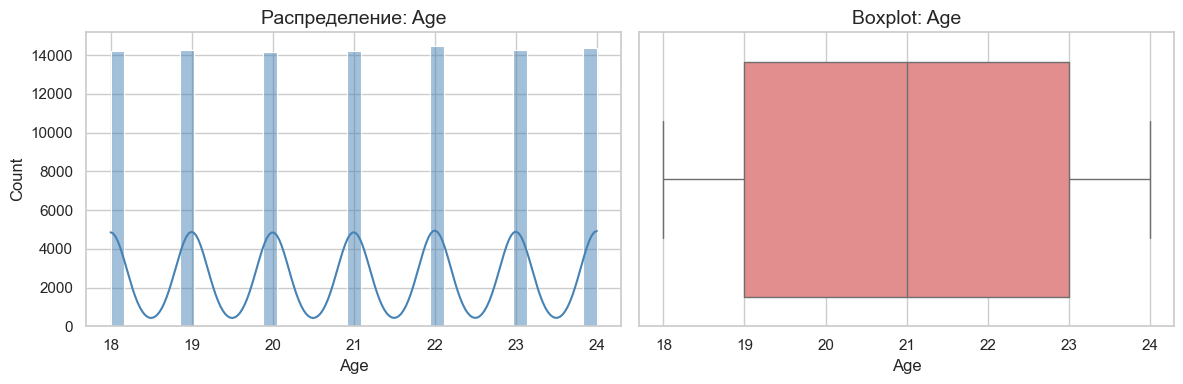

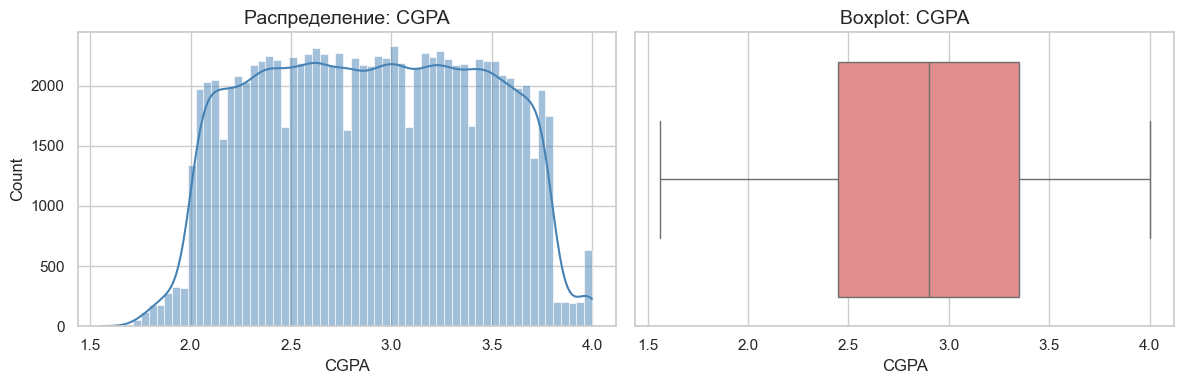

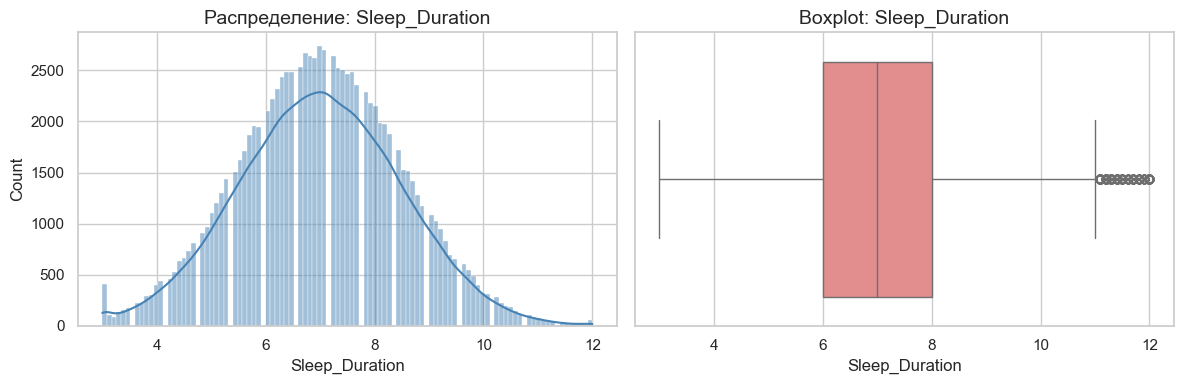

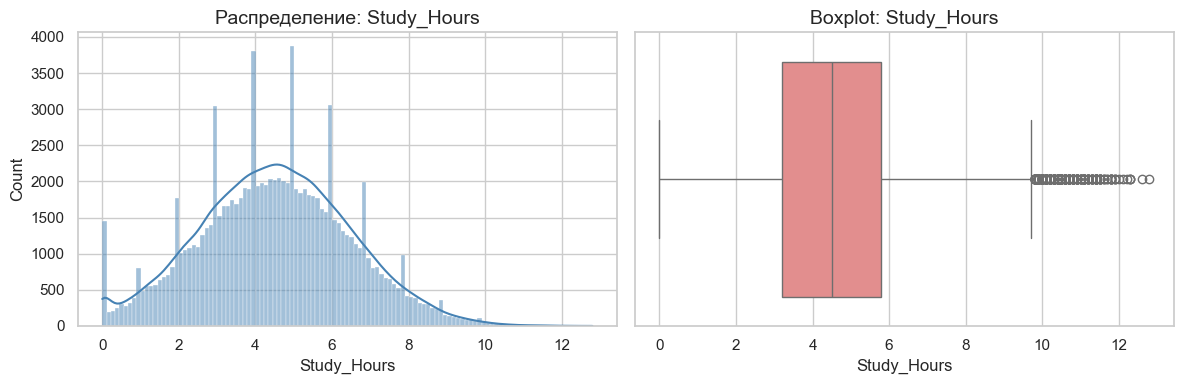

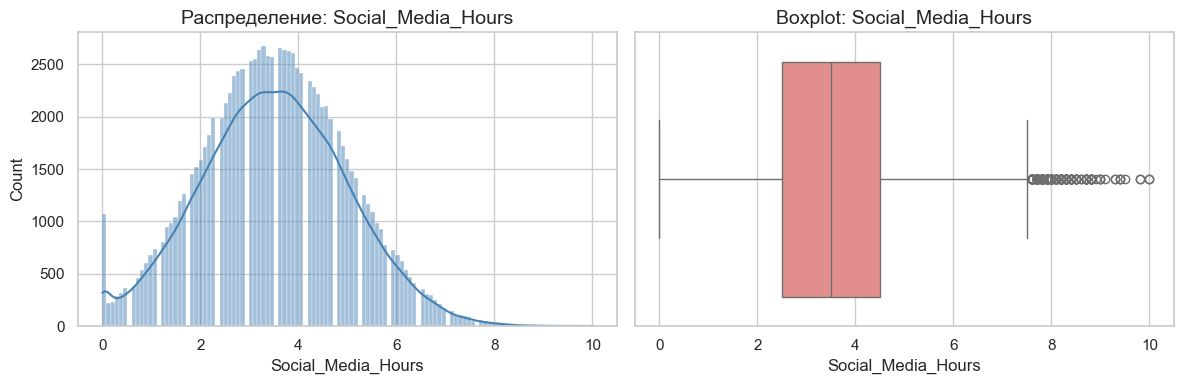

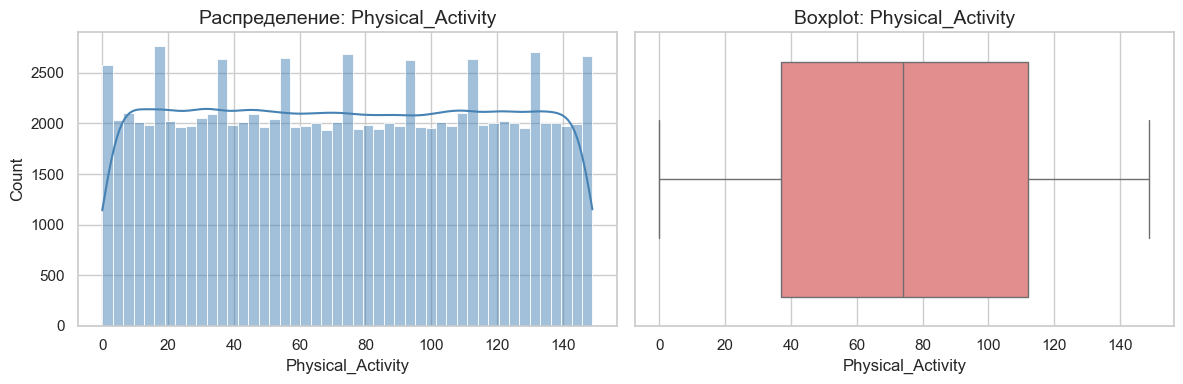

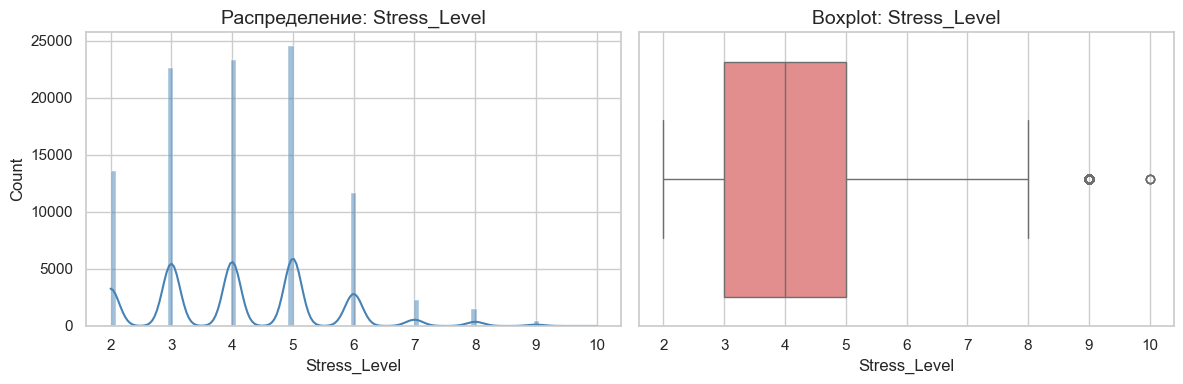

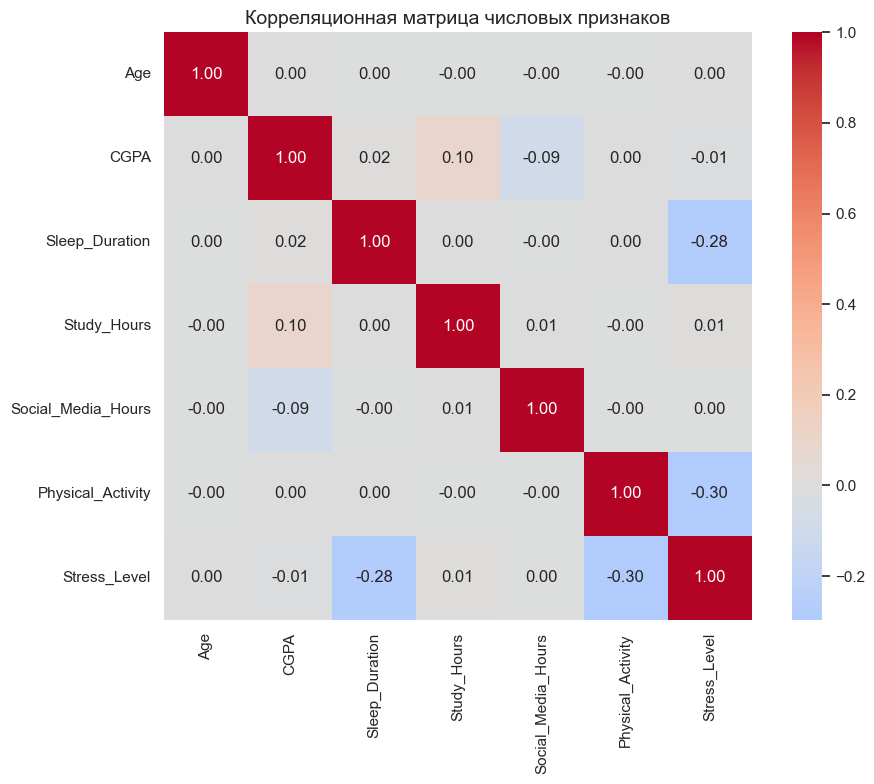

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')


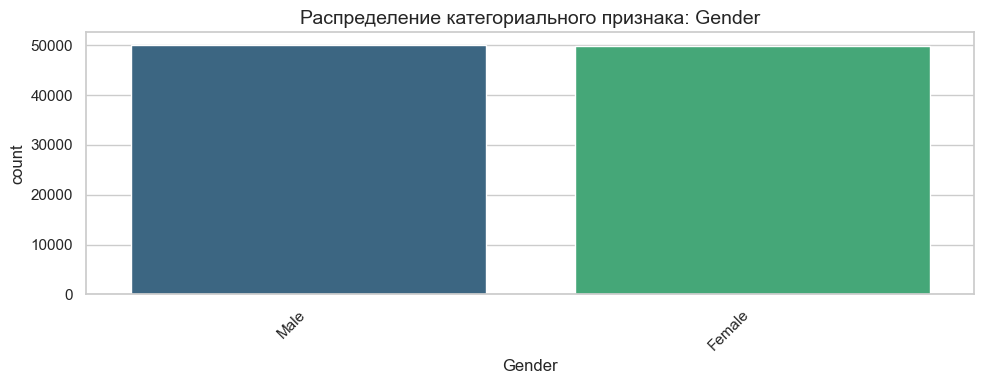

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')


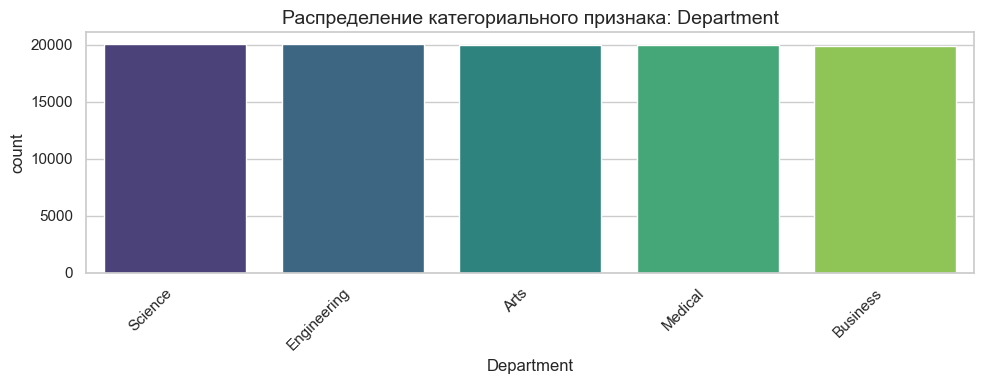

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')


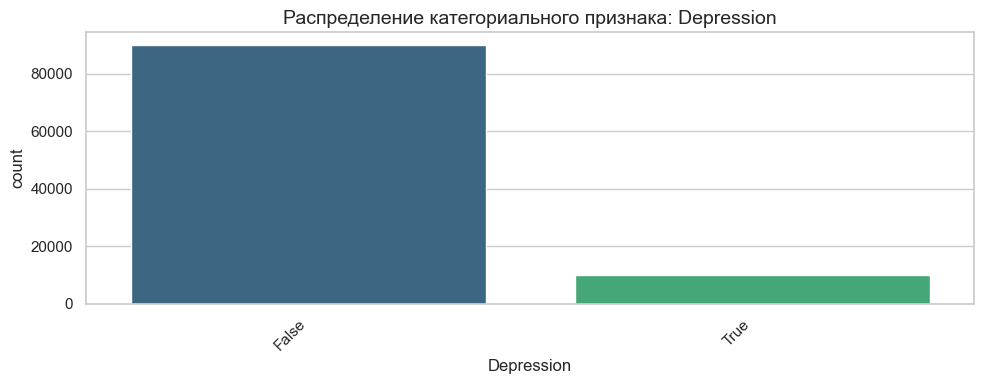

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=depression_counts.index, y=depression_counts.values, palette='Set2')


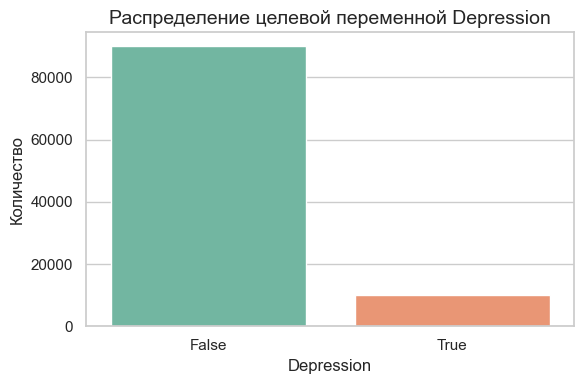

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette='Set3')


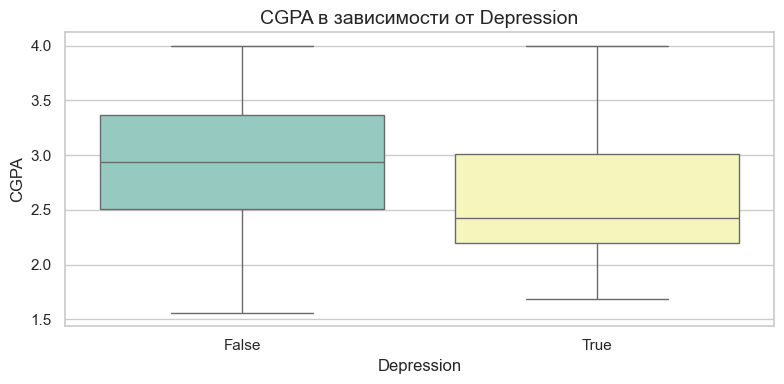

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette='Set3')


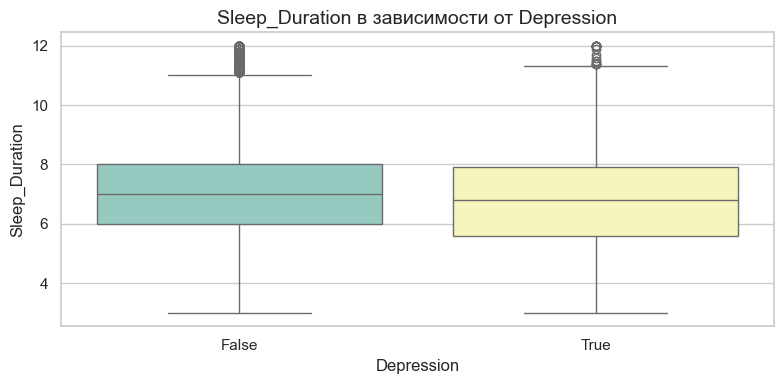

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette='Set3')


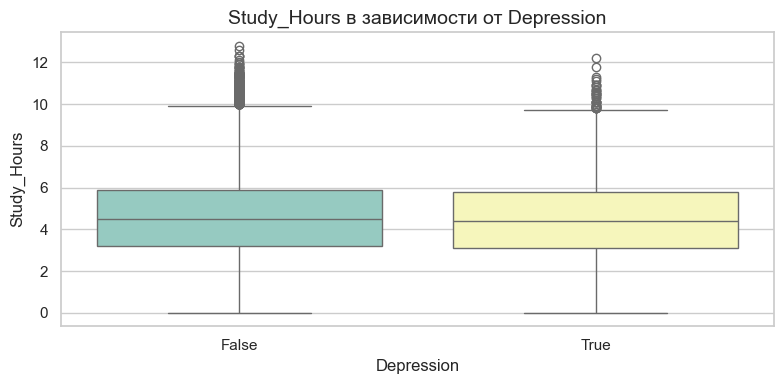

C:\Users\1\AppData\Local\Temp\ipykernel_24808\1785497881.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Depression', y=col, palette='Set3')


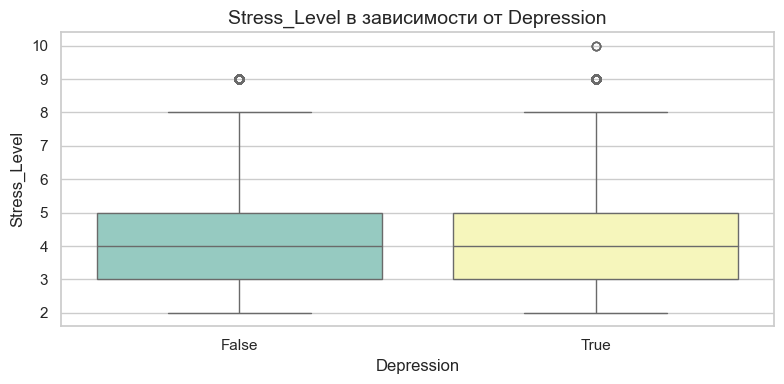

Краткие выводы по EDA:
- Student_ID исключен из визуализации, так как это служебный идентификатор.
- Числовые признаки проверены на распределения, выбросы и взаимные корреляции.
- Категориальные признаки с небольшой кардинальностью визуализированы через частоты.
- Распределение Depression и его связь с ключевыми факторами помогают понять качество данных и будущую задачу классификации.


In [34]:
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns.tolist() if col != 'Student_ID']
cat_cols = [col for col in df.select_dtypes(exclude=['number']).columns.tolist() if df[col].nunique(dropna=False) <= 20]

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Распределение: {col}')
    sns.boxplot(x=df[col], ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()

if numeric_cols:
    plt.figure(figsize=(10, 8))
    corr = df[numeric_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
    plt.title('Корреляционная матрица числовых признаков')
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='viridis')
    plt.title(f'Распределение категориального признака: {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

if 'Depression' in df.columns:
    plt.figure(figsize=(6, 4))
    depression_counts = df['Depression'].astype(str).value_counts()
    sns.barplot(x=depression_counts.index, y=depression_counts.values, palette='Set2')
    plt.title('Распределение целевой переменной Depression')
    plt.xlabel('Depression')
    plt.ylabel('Количество')
    plt.tight_layout()
    plt.show()

for col in ['CGPA', 'Sleep_Duration', 'Study_Hours', 'Stress_Level']:
    if col in df.columns and 'Depression' in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x='Depression', y=col, palette='Set3')
        plt.title(f'{col} в зависимости от Depression')
        plt.tight_layout()
        plt.show()

print('Краткие выводы по EDA:')
print('- Student_ID исключен из визуализации, так как это служебный идентификатор.')
print('- Числовые признаки проверены на распределения, выбросы и взаимные корреляции.')
print('- Категориальные признаки с небольшой кардинальностью визуализированы через частоты.')
print('- Распределение Depression и его связь с ключевыми факторами помогают понять качество данных и будущую задачу классификации.')

## 2. Минимальная предобработка данных
Так как в EDA уже подтверждено отсутствие критичных выбросов,
здесь оставляем только базовую очистку:

- приведение Depression к числовому виду (0/1)
- удаление дубликатов

In [35]:
df_prep = df.copy()

if 'Depression' in df_prep.columns:
    df_prep['Depression'] = (
        df_prep['Depression']
        .astype(str)
        .str.lower()
        .map({'true': 1, 'false': 0, '1': 1, '0': 0})
    )

df_prep = df_prep.drop_duplicates().reset_index(drop=True)

print('Минимальная предобработка завершена:')
print('Строк после удаления дубликатов:', len(df_prep))
print('Пропусков всего:', int(df_prep.isna().sum().sum()))

Минимальная предобработка завершена:
Строк после удаления дубликатов: 100000
Пропусков всего: 0


## 3. Feature engineering и отбор релевантных признаков

Что делаем в этом пункте:
- создаем новые информативные признаки на основе режима жизни;
- убираем признаки с нулевой/почти нулевой вариативностью;
- оцениваем связь числовых признаков с целями (CGPA, Depression);
- формируем итоговый набор признаков для моделей.

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

feat_df = df_prep.copy()

if {'Study_Hours', 'Sleep_Duration'}.issubset(feat_df.columns):
    feat_df['study_sleep_ratio'] = feat_df['Study_Hours'] / (feat_df['Sleep_Duration'] + 1e-6)

if {'Stress_Level', 'Physical_Activity'}.issubset(feat_df.columns):
    feat_df['stress_activity_ratio'] = feat_df['Stress_Level'] / (feat_df['Physical_Activity'] + 1e-6)

if {'Social_Media_Hours', 'Study_Hours'}.issubset(feat_df.columns):
    feat_df['social_vs_study'] = feat_df['Social_Media_Hours'] - feat_df['Study_Hours']

if 'Sleep_Duration' in feat_df.columns:
    feat_df['low_sleep_flag'] = (feat_df['Sleep_Duration'] < 6).astype(int)

candidate_features = [c for c in feat_df.columns if c not in ['Student_ID', 'CGPA', 'Depression']]
low_variance_cols = [c for c in candidate_features if feat_df[c].nunique(dropna=False) <= 1]
selected_features = [c for c in candidate_features if c not in low_variance_cols]

num_selected = feat_df[selected_features].select_dtypes(include=['number']).columns.tolist()

corr_with_cgpa = pd.Series(dtype='float64')
if 'CGPA' in feat_df.columns and num_selected:
    corr_with_cgpa = (
        feat_df[num_selected + ['CGPA']]
        .corr(numeric_only=True)['CGPA']
        .drop('CGPA')
        .abs()
        .sort_values(ascending=False)
    )

corr_with_depression = pd.Series(dtype='float64')
if 'Depression' in feat_df.columns and num_selected:
    corr_with_depression = (
        feat_df[num_selected + ['Depression']]
        .corr(numeric_only=True)['Depression']
        .drop('Depression')
        .abs()
        .sort_values(ascending=False)
    )

print('Добавленные engineered-признаки:')
print([c for c in feat_df.columns if c not in df_prep.columns])
print('\nУдалены как низковариативные:')
print(low_variance_cols if low_variance_cols else 'Нет')
print('\nИтоговое число признаков:', len(selected_features))

print('\nТоп-10 по |corr| с CGPA:')
display(corr_with_cgpa.head(10))

print('Топ-10 по |corr| с Depression:')
display(corr_with_depression.head(10))

X_final = feat_df[selected_features].copy()
y_reg_final = feat_df['CGPA'].copy()
y_cls_final = feat_df['Depression'].copy()

num_final = X_final.select_dtypes(include=['number']).columns.tolist()
cat_final = X_final.select_dtypes(exclude=['number']).columns.tolist()

preprocessor_final = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_final),
    ('cat', Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), cat_final)
])

print('\nГотово: X_final, y_reg_final, y_cls_final и preprocessor_final подготовлены.')

Добавленные engineered-признаки:
['study_sleep_ratio', 'stress_activity_ratio', 'social_vs_study', 'low_sleep_flag']

Удалены как низковариативные:
Нет

Итоговое число признаков: 12

Топ-10 по |corr| с CGPA:


social_vs_study          0.132781
Study_Hours              0.099534
Social_Media_Hours       0.087998
study_sleep_ratio        0.073375
Sleep_Duration           0.015386
Stress_Level             0.012287
low_sleep_flag           0.011194
Physical_Activity        0.004766
stress_activity_ratio    0.003502
Age                      0.003248
Name: CGPA, dtype: float64

Топ-10 по |corr| с Depression:


Stress_Level             0.075866
Sleep_Duration           0.057529
low_sleep_flag           0.048775
study_sleep_ratio        0.023005
social_vs_study          0.022872
Social_Media_Hours       0.016771
Study_Hours              0.015932
Physical_Activity        0.013935
Age                      0.007722
stress_activity_ratio    0.001231
Name: Depression, dtype: float64


Готово: X_final, y_reg_final, y_cls_final и preprocessor_final подготовлены.


Обоснование выбора признаков:
- Student_ID исключен как служебный идентификатор без предиктивного смысла;
- добавлены производные признаки (study_sleep_ratio, stress_activity_ratio, social_vs_study, low_sleep_flag), так как они лучше отражают поведенческие паттерны;
- исключены низковариативные признаки, которые почти не добавляют информации модели;
- релевантность подтверждена ранжированием по модулю корреляции с CGPA и Depression.

## 4. Разделение данных на обучающую, валидационную и тестовую выборки (без утечки)

На этом шаге делим данные до обучения моделей и любых преобразований признаков.

Принцип без утечки данных:
- сначала отделяем тестовую выборку;
- затем из оставшейся части выделяем валидационную;
- все преобразования (`imputer`, `scaler`, `encoder`) обучаются только на train-части.

In [37]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
VAL_SIZE = 0.2
RANDOM_STATE = 42

X_train_full, X_test, y_reg_train_full, y_reg_test, y_cls_train_full, y_cls_test = train_test_split(
    X_final,
    y_reg_final,
    y_cls_final,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_cls_final
)

val_relative_size = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_reg_train, y_reg_val, y_cls_train, y_cls_val = train_test_split(
    X_train_full,
    y_reg_train_full,
    y_cls_train_full,
    test_size=val_relative_size,
    random_state=RANDOM_STATE,
    stratify=y_cls_train_full
)

print("Размеры выборок (признаки):")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nДоли классов Depression (контроль стратификации):")
print("Train:\n", y_cls_train.value_counts(normalize=True).sort_index())
print("Validation:\n", y_cls_val.value_counts(normalize=True).sort_index())
print("Test:\n", y_cls_test.value_counts(normalize=True).sort_index())

print("\nГотово: данные разделены без утечки.")

Размеры выборок (признаки):
X_train: (60000, 12)
X_val: (20000, 12)
X_test: (20000, 12)

Доли классов Depression (контроль стратификации):
Train:
 Depression
0    0.899367
1    0.100633
Name: proportion, dtype: float64
Validation:
 Depression
0    0.8994
1    0.1006
Name: proportion, dtype: float64
Test:
 Depression
0    0.8994
1    0.1006
Name: proportion, dtype: float64

Готово: данные разделены без утечки.


## 5. Linear Regression для CGPA
В этом разделе я обучаю модель линейной регрессии для предсказания CGPA по признакам, связанным с режимом учебы, сна и повседневной активности студента.

Чтобы избежать утечки данных, модель обучается только на обучающей выборке. Сначала признаки преобразуются с помощью preprocessor_final, который содержит обработку пропусков, масштабирование числовых признаков и кодирование категориальных. После этого модель проверяется на валидационной и тестовой выборках, чтобы оценить качество обобщения.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

X_train_processed = preprocessor_final.fit_transform(X_train)
X_val_processed = preprocessor_final.transform(X_val)
X_test_processed = preprocessor_final.transform(X_test)

print("Размер обработанных матриц:")
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)

Размер обработанных матриц:
X_train_processed: (60000, 17)
X_val_processed: (20000, 17)
X_test_processed: (20000, 17)


In [39]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train_processed, y_reg_train)

y_train_pred = linear_regression_model.predict(X_train_processed)
y_val_pred = linear_regression_model.predict(X_val_processed)
y_test_pred = linear_regression_model.predict(X_test_processed)

def regression_metrics(y_true, y_pred, sample_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "sample": sample_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

metrics_df = pd.DataFrame([
    regression_metrics(y_reg_train, y_train_pred, "train"),
    regression_metrics(y_reg_val, y_val_pred, "validation"),
    regression_metrics(y_reg_test, y_test_pred, "test")
])

display(metrics_df)

,sample,RMSE,MAE,R2
0,train,0.527288,0.454632,0.017974
1,validation,0.527504,0.454605,0.017943
2,test,0.527481,0.453882,0.019173


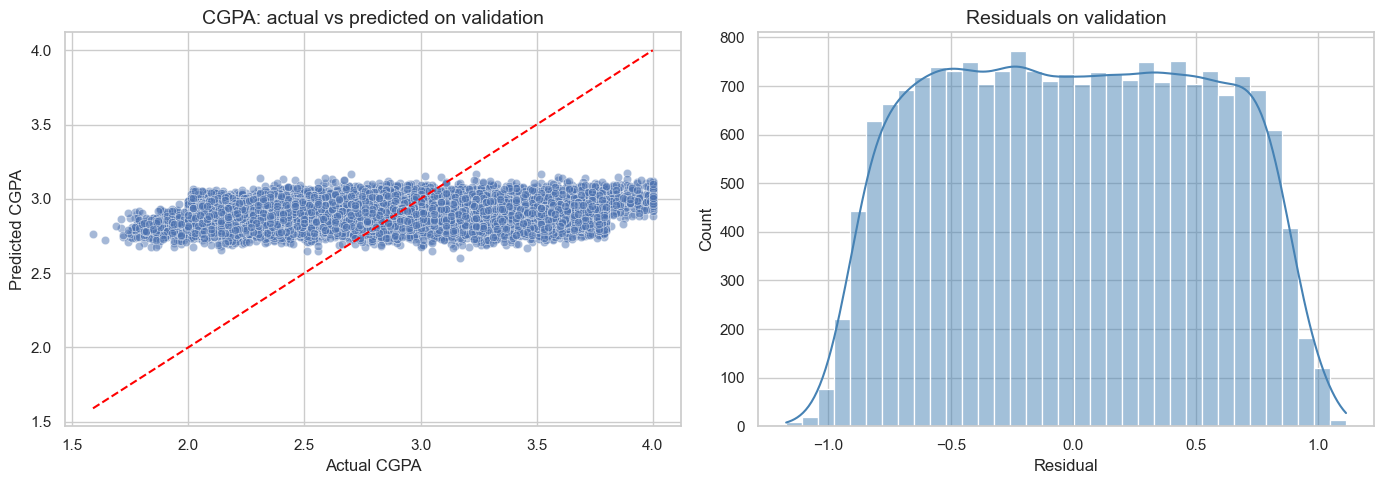

Краткий вывод:
- Если метрики на train заметно лучше, чем на validation и test, это признак переобучения.
- Если метрики близки между train, validation и test, модель обобщает стабильно.


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_reg_val, y=y_val_pred, ax=axes[0], alpha=0.5)
axes[0].plot([y_reg_val.min(), y_reg_val.max()], [y_reg_val.min(), y_reg_val.max()], color="red", linestyle="--")
axes[0].set_title("CGPA: actual vs predicted on validation")
axes[0].set_xlabel("Actual CGPA")
axes[0].set_ylabel("Predicted CGPA")

val_residuals = y_reg_val - y_val_pred
sns.histplot(val_residuals, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Residuals on validation")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print("Краткий вывод:")
print("- Если метрики на train заметно лучше, чем на validation и test, это признак переобучения.")
print("- Если метрики близки между train, validation и test, модель обобщает стабильно.")